# Global Nutrition Sales Intelligence

## Python Sales Analysis

### Objective

This notebook connects to the PostgreSQL database, loads cleaned sales data and reporting views, performs exploratory data analysis (EDA), creates supporting visualizations, and provides business insights to complement the Power BI dashboard.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Database connection
import psycopg2
from sqlalchemy import create_engine

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Plot style
sns.set_theme(style="whitegrid")

In [2]:
# PostgreSQL connection details
DB_USER = "postgres"
DB_PASSWORD = "********"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "nutriglobal"

# Create SQLAlchemy engine
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Connection established successfully!")

Connection established successfully!


In [3]:
query = "SELECT COUNT(*) AS total_rows FROM cleaned_supplement_sales"

pd.read_sql(query, engine)

,total_rows
0,4384


In [4]:
main_df = pd.read_sql(
    "SELECT * FROM cleaned_supplement_sales",
    engine
)

sales_df = pd.read_sql("SELECT * FROM vw_sales_overview", engine)

country_df = pd.read_sql("SELECT * FROM vw_country_performance", engine)

category_df = pd.read_sql("SELECT * FROM vw_category_performance", engine)

platform_df = pd.read_sql("SELECT * FROM vw_platform_performance", engine)

monthly_df = pd.read_sql("SELECT * FROM vw_monthly_sales_trend", engine)

product_df = pd.read_sql("SELECT * FROM vw_product_performance", engine)

In [5]:
main_df.shape

(4384, 10)

In [6]:
print("Sales Overview:", sales_df.shape)
print("Country:", country_df.shape)
print("Category:", category_df.shape)
print("Platform:", platform_df.shape)
print("Monthly:", monthly_df.shape)
print("Product:", product_df.shape)

Sales Overview: (1, 4)
Country: (3, 5)
Category: (10, 6)
Platform: (3, 5)
Monthly: (63, 4)
Product: (16, 6)


In [7]:
sales_df.head()

,total_revenue,total_units_sold,total_units_returned,avg_order_value
0,"22,913,280.45",658478,6714,"5,226.57"


In [8]:
country_df.head()

,location,total_revenue,total_units_sold,total_units_returned,avg_order_value
0,Canada,"7,848,579.73",226053,2259,"5,208.08"
1,UK,"7,703,960.34",221237,2327,"5,223.02"
2,USA,"7,360,740.38",211188,2128,"5,250.17"


In [9]:
category_df.head()

,category,total_revenue,total_units_sold,total_units_returned,avg_discount,revenue_pct
0,Vitamin,"4,300,224.68",123434,1293,0.13,18.77
1,Mineral,"4,276,107.99",123668,1251,0.13,18.66
2,Performance,"2,909,702.18",82523,841,0.12,12.70
3,Protein,"2,855,492.09",82120,836,0.12,12.46
4,Amino Acid,"1,464,819.63",41027,428,0.12,6.39


In [10]:
platform_df.head()

,platform,total_revenue,total_units_sold,total_units_returned,avg_order_value
0,iHerb,"7,855,261.05",225427,2291,"5,240.33"
1,Amazon,"7,669,451.78",220623,2295,"5,206.69"
2,Walmart,"7,388,567.62",212428,2128,"5,232.70"


In [11]:
monthly_df.head()

,month,total_revenue,total_units_sold,total_units_returned
0,2020-01-01,"290,723.89",9547,101
1,2020-02-01,"355,213.26",9493,91
2,2020-03-01,"416,547.17",12145,123
3,2020-04-01,"326,287.92",9605,91
4,2020-05-01,"333,210.99",9557,90


In [12]:
product_df.head()

,product_name,category,total_revenue,total_units_sold,total_units_returned,return_rate_pct
0,Biotin,Vitamin,"1,486,798.62",41533,411,0.99
1,Zinc,Mineral,"1,482,546.95",41204,394,0.96
2,Pre-Workout,Performance,"1,477,183.78",41287,426,1.03
3,BCAA,Amino Acid,"1,464,819.63",41027,428,1.04
4,Fish Oil,Omega,"1,451,065.87",41325,407,0.98


## Dataset Overview

This section explores the structure, quality, and summary statistics of the main sales dataset before performing exploratory data analysis.

In [13]:
print(f"Rows: {main_df.shape[0]}")
print(f"Columns: {main_df.shape[1]}")                  ##Dataset Shape

Rows: 4384
Columns: 10


In [14]:
main_df.info()                                             ##Dataset Information

<class 'pandas.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4384 non-null   object 
 1   product_name    4384 non-null   str    
 2   category        4384 non-null   str    
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   float64
 5   revenue         4384 non-null   float64
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   str    
 9   platform        4384 non-null   str    
dtypes: float64(3), int64(2), object(1), str(4)
memory usage: 342.6+ KB


In [15]:
main_df.describe()                                                ##Summary Statistics

,units_sold,price,revenue,discount,units_returned
count,"4,384.00","4,384.00","4,384.00","4,384.00","4,384.00"
mean,150.20,34.78,"5,226.57",0.12,1.53
std,12.40,14.20,"2,192.49",0.07,1.26
min,103.00,10.00,"1,284.00",0.00,0.00
25%,142.00,22.60,"3,349.37",0.06,1.00
50%,150.00,34.72,"5,173.14",0.12,1.00
75%,158.00,46.71,"7,009.96",0.19,2.00
max,194.00,59.97,"10,761.85",0.25,8.00


In [16]:
main_df.isnull().sum()                                      ##Missing Values

date              0
product_name      0
category          0
units_sold        0
price             0
revenue           0
discount          0
units_returned    0
location          0
platform          0
dtype: int64

In [17]:
main_df.duplicated().sum()                                   ##Duplicate Values

np.int64(0)

In [18]:
main_df.columns                                             ##Display Column Names

Index(['date', 'product_name', 'category', 'units_sold', 'price', 'revenue',
       'discount', 'units_returned', 'location', 'platform'],
      dtype='str')

## Univariate Analysis

This section explores the distribution of key variables and summarizes important characteristics of the sales data using visualizations.

##  Revenue Distribution

### Business Objective

This visualization examines the distribution of revenue across individual sales transactions. It helps identify the concentration of transaction values, overall spread, and whether the revenue distribution is symmetric or skewed.

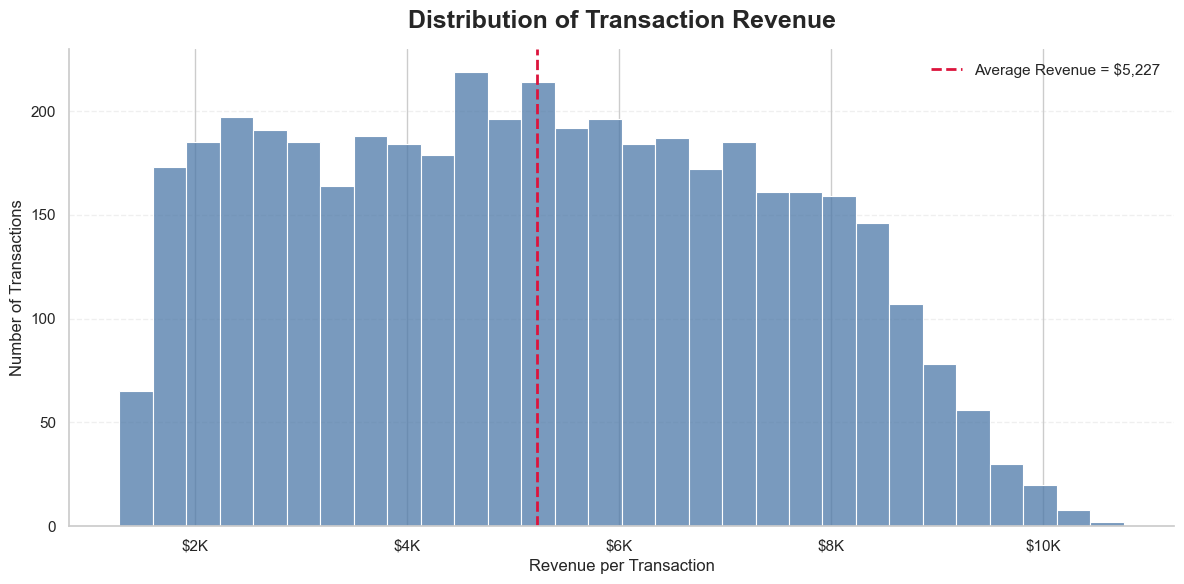

In [19]:
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=main_df,
    x="revenue",
    bins=30,
    color="#4C78A8",      # Professional blue
    edgecolor="white",
    linewidth=0.8
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.title(
    "Distribution of Transaction Revenue",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Revenue per Transaction",
    fontsize=12
)

plt.ylabel(
    "Number of Transactions",
    fontsize=12
)

sns.despine()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

mean_rev = main_df["revenue"].mean()

plt.axvline(
    mean_rev,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Average Revenue = ${mean_rev:,.0f}"
)

plt.legend(frameon=False)

plt.show()

### Key Findings

- Most transactions fall between approximately **$3K and $8K**, indicating a relatively consistent purchase value.
- The revenue distribution is moderately spread with no evidence of extreme transaction values.

##  Revenue Distribution (Boxplot)

### Business Objective

Identify the spread, median, and potential outliers in transaction revenue.

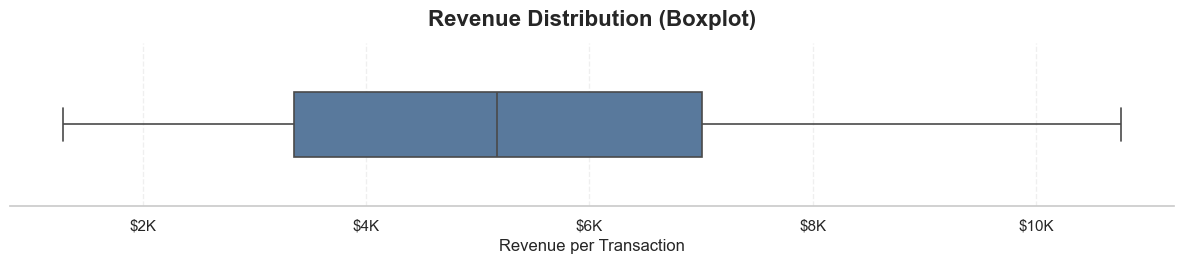

In [20]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 2.8))

ax = sns.boxplot(
    x=main_df["revenue"],
    color="#4E79A7",
    width=0.4,
    linewidth=1.2,
    fliersize=4
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.title(
    "Revenue Distribution (Boxplot)",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel(
    "Revenue per Transaction",
    fontsize=12
)

sns.despine(left=True)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Key Findings

- The median transaction revenue is approximately **$5.2K**, with most transactions concentrated within a moderate range.
- No significant outliers are observed, indicating a relatively consistent revenue distribution.

##  Revenue by Product Category

### Business Objective

Compare total revenue generated across product categories to identify the highest-performing categories.

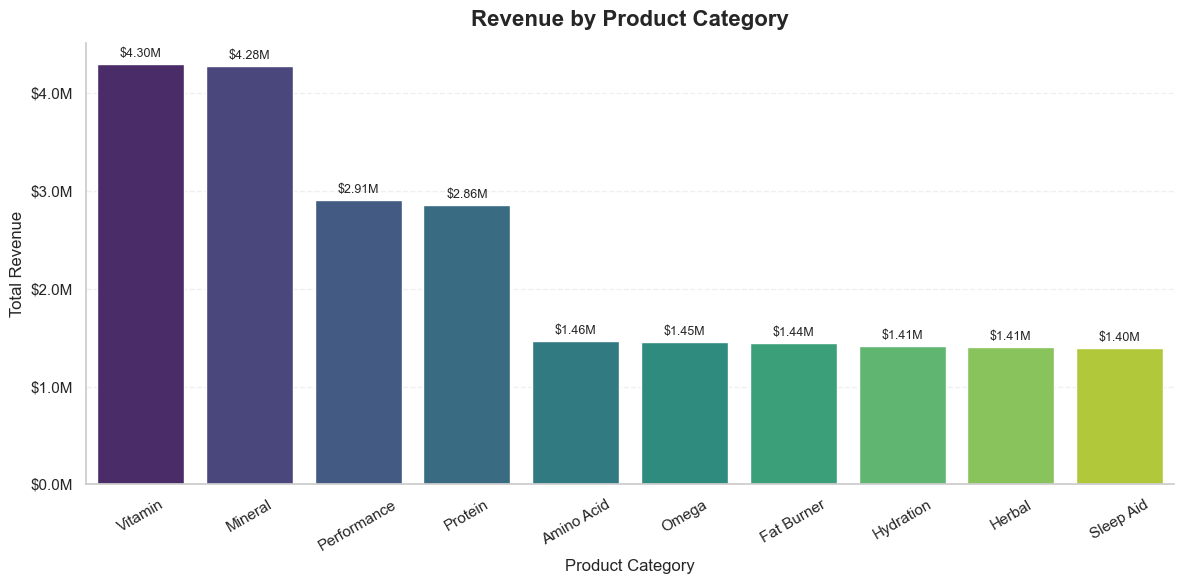

In [21]:
# ----------------------------------------
# U-03: Revenue by Product Category
# ----------------------------------------

# Sort categories by revenue
category_sorted = category_df.sort_values(
    by="total_revenue",
    ascending=False
)

# Create figure
plt.figure(figsize=(12, 6))

# Create color palette
palette = sns.color_palette("viridis", len(category_sorted))

# Create bar chart
ax = sns.barplot(
    data=category_sorted,
    x="category",
    y="total_revenue",
    hue="category",
    palette="viridis",
    legend=False
)


# Format y-axis as millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

# Add value labels
for container in ax.containers:
    labels = [f'${v/1_000_000:.2f}M' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        fontsize=9,
        padding=3
    )

# Titles and labels
plt.title(
    "Revenue by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.xticks(rotation=30)

# Styling
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- **Vitamin** and **Mineral** categories generated the highest revenue, each contributing over **$4.2M** in sales.
- The remaining categories showed a gradual decline in revenue, with the bottom six categories generating relatively similar sales levels.

##  Revenue by Country

### Business Objective

Compare total revenue generated across different countries to identify the strongest performing market.

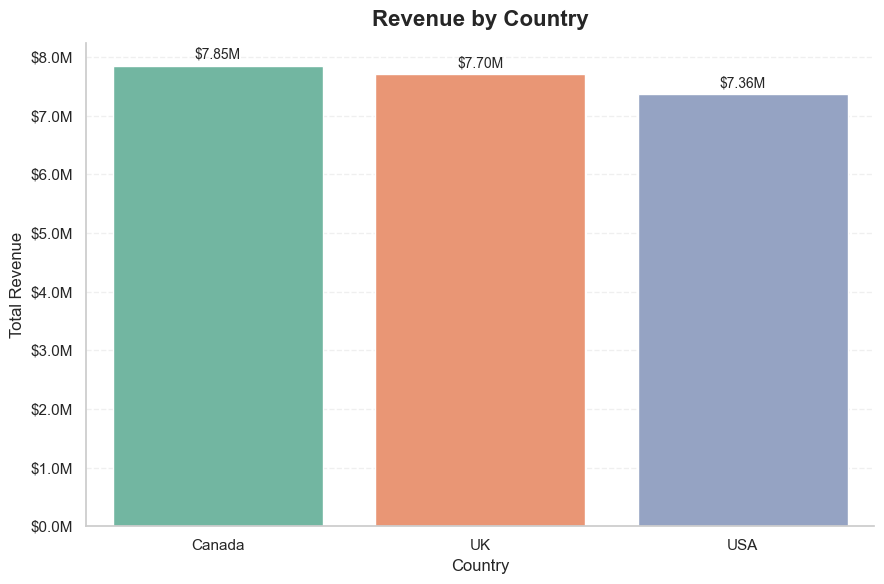

In [22]:
# ----------------------------------------
# U-04: Revenue by Country
# ----------------------------------------

# Sort countries by revenue
country_sorted = country_df.sort_values(
    by="total_revenue",
    ascending=False
)

# Create figure
plt.figure(figsize=(9, 6))

# Create color palette
palette = sns.color_palette("Set2", len(country_sorted))

# Create bar chart
ax = sns.barplot(
    data=country_sorted,
    x="location",
    y="total_revenue",
    hue="location",
    palette=palette,
    legend=False
)

# Format y-axis as millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

# Add value labels
for container in ax.containers:
    labels = [f'${v/1_000_000:.2f}M' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=10
    )

# Titles and labels
plt.title(
    "Revenue by Country",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

# Styling
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- **Canada** generated the highest total revenue (**$7.85M**), followed closely by the **UK** (**$7.70M**).
- Revenue distribution across all three countries is relatively balanced, with no market showing a substantial performance gap.

##  Revenue by Sales Platform

### Business Objective

Compare revenue generated across sales platforms to identify the strongest-performing sales channel.

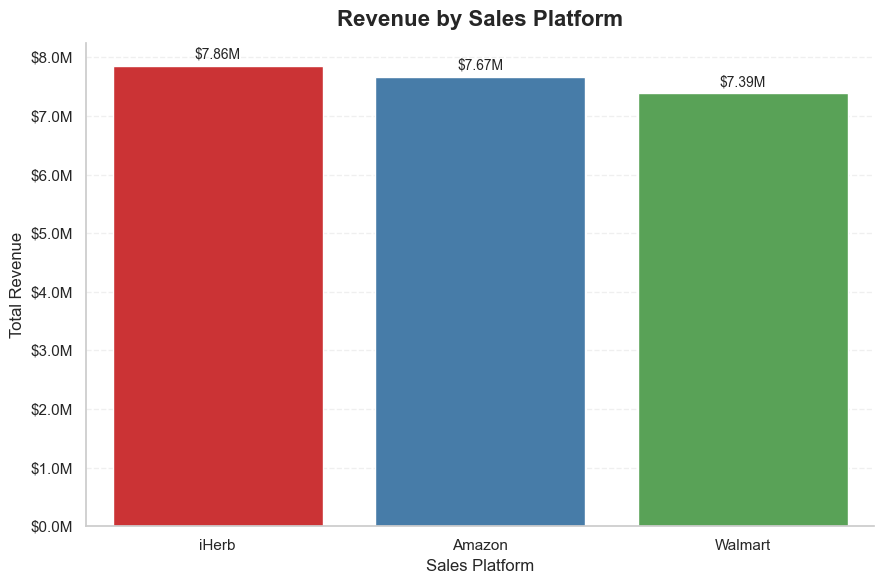

In [23]:
# ----------------------------------------
# U-05: Revenue by Sales Platform
# ----------------------------------------

# Sort platforms by revenue
platform_sorted = platform_df.sort_values(
    by="total_revenue",
    ascending=False
)

# Create figure
plt.figure(figsize=(9, 6))

# Create color palette
palette = sns.color_palette("Set1", len(platform_sorted))

# Create bar chart
ax = sns.barplot(
    data=platform_sorted,
    x="platform",
    y="total_revenue",
    hue="platform",
    palette=palette,
    legend=False
)

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

# Add value labels
for container in ax.containers:
    labels = [f'${v/1_000_000:.2f}M' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=10
    )

# Titles and labels
plt.title(
    "Revenue by Sales Platform",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Sales Platform", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

# Styling
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- **iHerb** generated the highest revenue (**$7.86M**), narrowly outperforming **Amazon** (**$7.67M**).
- Revenue across all three sales platforms is relatively balanced, indicating consistent sales performance across channels.

##  Monthly Revenue Trend

### Business Objective

Analyze monthly revenue trends to identify seasonality and fluctuations in sales performance over time.

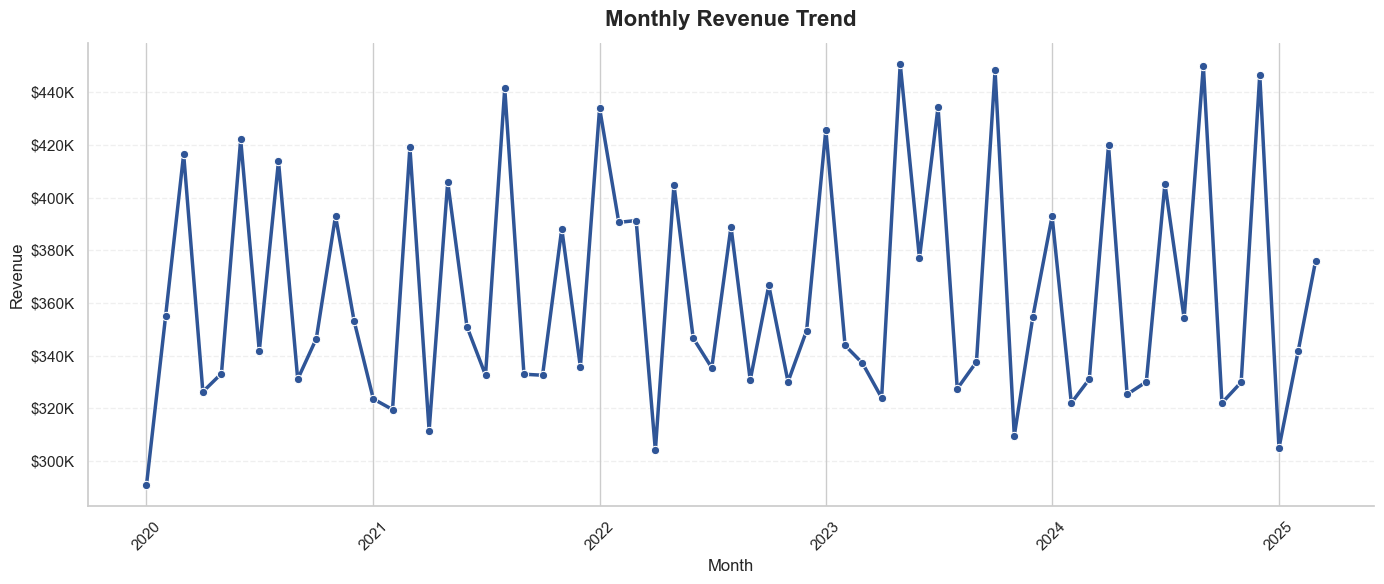

In [24]:
# ----------------------------------------
# U-06: Monthly Revenue Trend
# ----------------------------------------

# Create figure
plt.figure(figsize=(14, 6))

# Create line chart
ax = sns.lineplot(
    data=monthly_df,
    x="month",
    y="total_revenue",
    marker="o",
    color="#2F5597",
    linewidth=2.5,
    markersize=6
)

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

# Titles and labels
plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Styling
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- Monthly revenue remained relatively stable throughout the analysis period, with recurring fluctuations between approximately **$300K** and **$450K**.
- No sustained upward or downward trend is observed, indicating consistent sales performance over time.

##  Top 10 Products by Revenue

### Business Objective

Identify the highest revenue-generating products to understand the strongest contributors to overall sales.

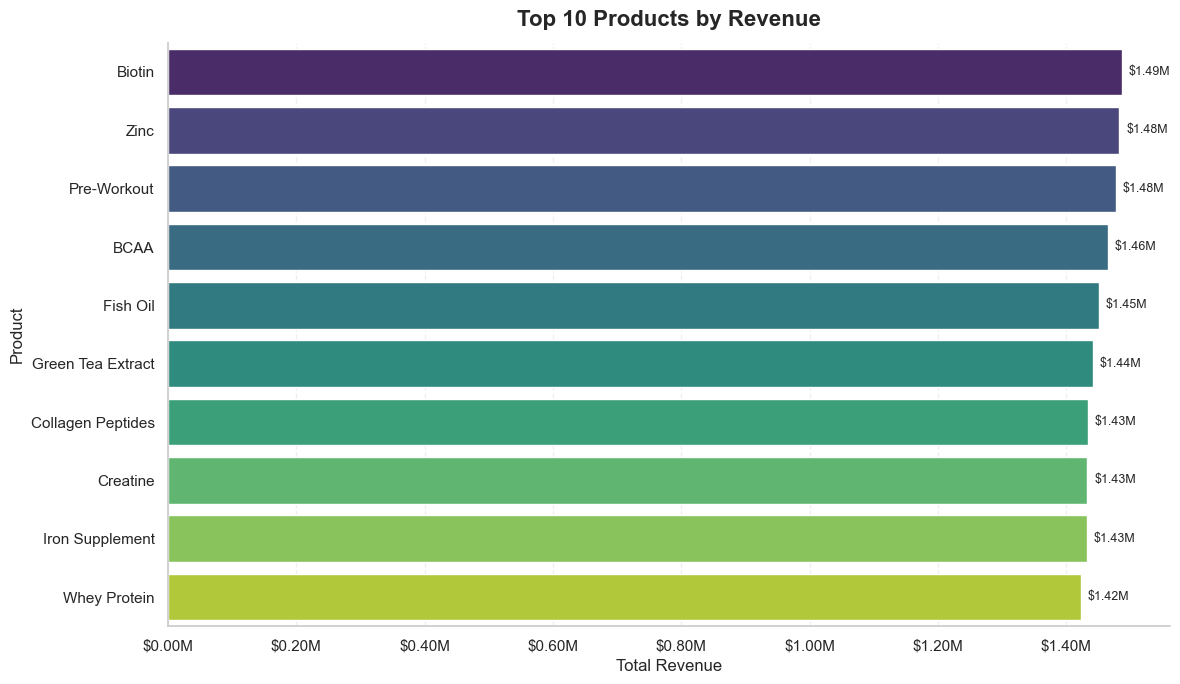

In [25]:
# ----------------------------------------
# U-07: Top 10 Products by Revenue
# ----------------------------------------

# Select top 10 products
top_products = (
    product_df.sort_values(by="total_revenue", ascending=False)
    .head(10)
)

# Create figure
plt.figure(figsize=(12, 7))

# Create color palette
palette = sns.color_palette("viridis", len(top_products))

# Create horizontal bar chart
ax = sns.barplot(
    data=top_products,
    x="total_revenue",
    y="product_name",
    hue="product_name",
    palette=palette,
    legend=False
)

# Format x-axis
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.2f}M')
)

# Add value labels
for container in ax.containers:
    labels = [f'${v/1_000_000:.2f}M' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=5,
        fontsize=9
    )

# Titles and labels
plt.title(
    "Top 10 Products by Revenue",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Total Revenue", fontsize=12)
plt.ylabel("Product", fontsize=12)

# Styling
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- **Biotin** generated the highest revenue (**$1.49M**), closely followed by **Zinc** and **Pre-Workout** supplements.
- Revenue among the top 10 products is relatively consistent, indicating balanced product performance rather than dependence on a single product.

# Bivariate Analysis

This section explores relationships between two variables to identify patterns and business insights.

## B-01: Revenue by Product Category Across Countries

### Business Objective

Compare category performance across countries to identify market-specific sales patterns.

In [26]:
category_country_df = pd.read_sql("""

SELECT
    location,
    category,
    ROUND(SUM(revenue),2) AS total_revenue
FROM cleaned_supplement_sales
GROUP BY location, category
ORDER BY location, total_revenue DESC;

""", engine)

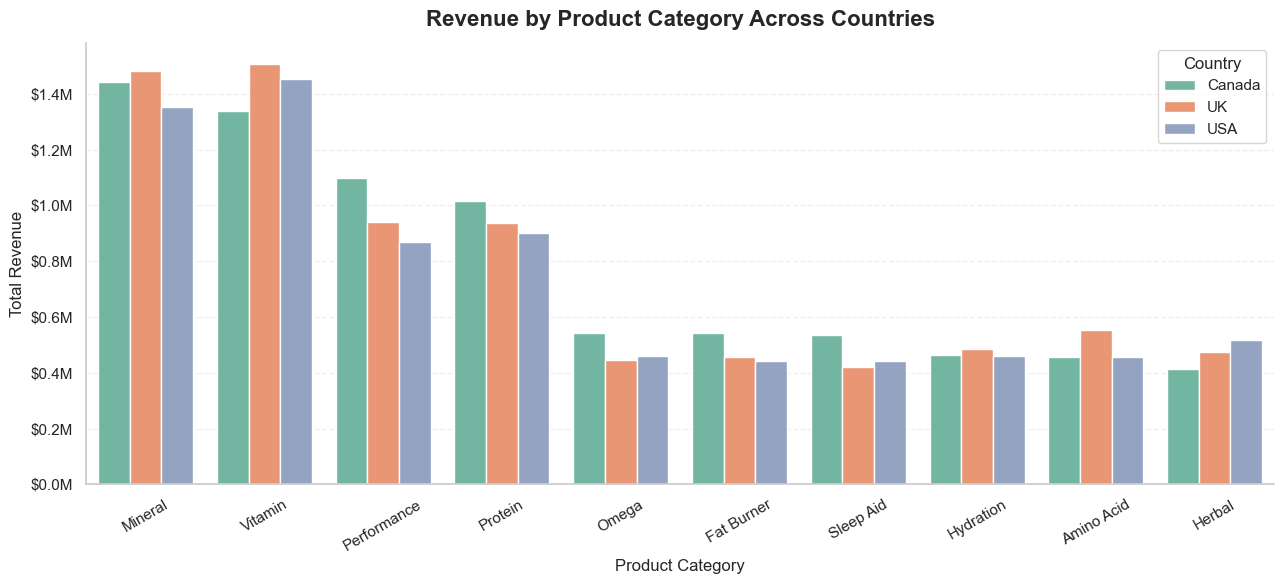

In [27]:
# ----------------------------------------
# B-01: Revenue by Product Category Across Countries
# ----------------------------------------

plt.figure(figsize=(13,6))

palette = sns.color_palette("Set2")

ax = sns.barplot(
    data=category_country_df,
    x="category",
    y="total_revenue",
    hue="location",
    palette=sns.color_palette("Set2", 3)
)


# Format currency
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

plt.title(
    "Revenue by Product Category Across Countries",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.legend(title="Country")

sns.despine()

plt.grid(axis="y", linestyle="--", alpha=.3)

plt.tight_layout()

plt.show()

### Key Findings

- **Vitamin** and **Mineral** consistently generated the highest revenue across all three countries.
- Product category performance remains broadly consistent across markets, with no major country-specific deviations.

## B-02: Revenue by Sales Platform Across Countries

### Business Objective

Compare platform performance across countries to identify the most effective sales channels in each market.

In [28]:
platform_country_df = pd.read_sql("""

SELECT
    location,
    platform,
    ROUND(SUM(revenue),2) AS total_revenue
FROM cleaned_supplement_sales
GROUP BY location, platform
ORDER BY location, total_revenue DESC;

""", engine)

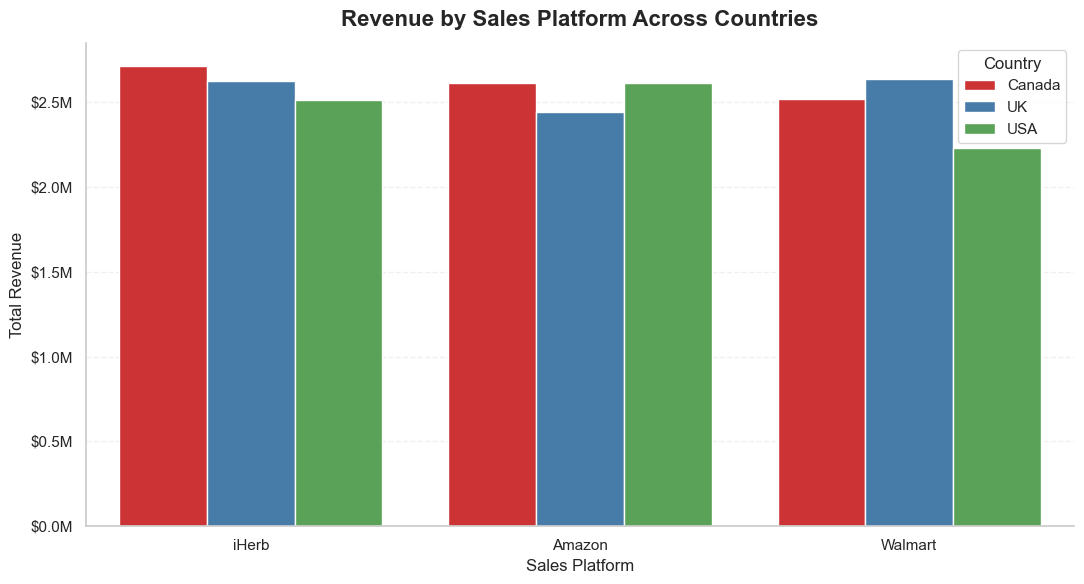

In [29]:
# ----------------------------------------
# B-02: Revenue by Sales Platform Across Countries
# ----------------------------------------

plt.figure(figsize=(11,6))

palette = sns.color_palette("Set1", n_colors=3)

ax = sns.barplot(
    data=platform_country_df,
    x="platform",
    y="total_revenue",
    hue="location",
    palette=palette

)

# Format currency
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

# Titles
plt.title(
    "Revenue by Sales Platform Across Countries",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Sales Platform", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

# Style
plt.legend(title="Country")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

### Key Findings

- **iHerb** generated the highest revenue in **Canada**, while **Walmart** performed best in the **UK** and **Amazon** led in the **USA**.
- Revenue across platforms remains relatively balanced within each country, indicating no single platform dominates all markets.

## B-03: Discount vs Revenue

### Business Objective

Analyze the relationship between discount levels and transaction revenue to understand whether higher discounts are associated with higher sales revenue.

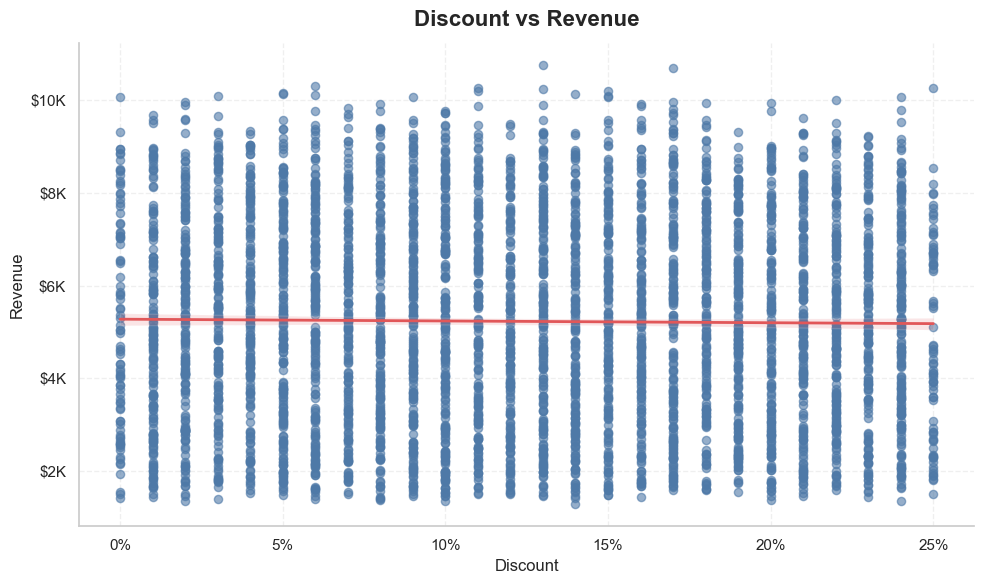

In [30]:
# ----------------------------------------
# B-03: Discount vs Revenue
# ----------------------------------------

# Create figure
plt.figure(figsize=(10, 6))

# Create scatter plot
ax = sns.regplot(
    data=main_df,
    x="discount",
    y="revenue",
    scatter_kws={
        "alpha": 0.6,
        "s": 35,
        "color": "#4E79A7"
    },
    line_kws={
        "color": "#E15759",
        "linewidth": 2
    }
)

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

# Format x-axis as percentage
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:.0%}')
)

# Titles
plt.title(
    "Discount vs Revenue",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Discount", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Styling
sns.despine()
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- Revenue remains relatively consistent across all discount levels, indicating **no strong relationship** between discount percentage and transaction revenue.
- The nearly flat regression line suggests that increasing discounts alone did not significantly influence revenue in this dataset.

## B-04: Units Sold vs Revenue

### Business Objective

Examine the relationship between units sold and transaction revenue to determine whether higher sales volume leads to increased revenue.

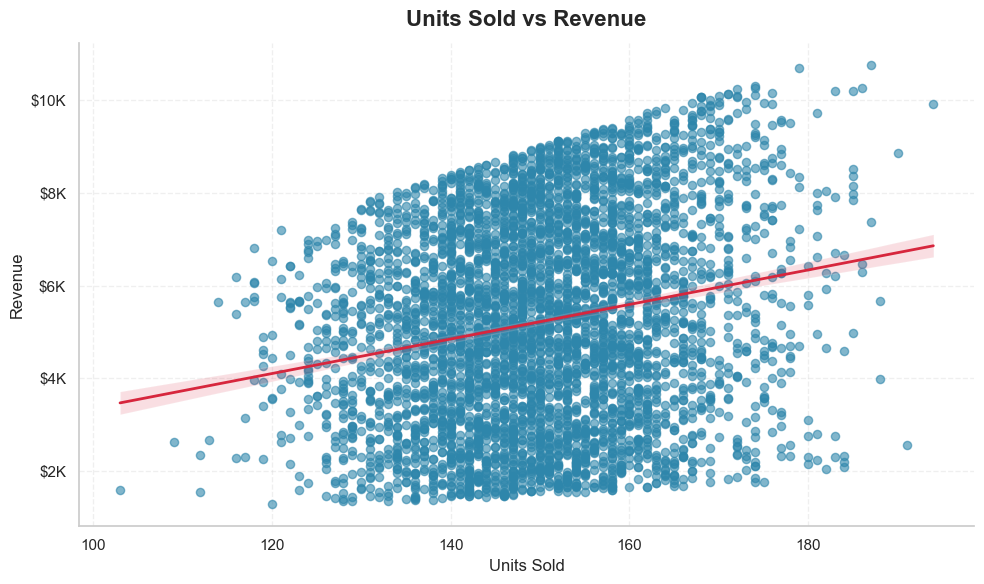

In [31]:
# ----------------------------------------
# B-04: Units Sold vs Revenue
# ----------------------------------------

# Create figure
plt.figure(figsize=(10, 6))

# Create scatter plot with regression line
ax = sns.regplot(
    data=main_df,
    x="units_sold",
    y="revenue",
    scatter_kws={
        "alpha": 0.6,
        "s": 35,
        "color": "#2E86AB"
    },
    line_kws={
        "color": "#D7263D",
        "linewidth": 2
    }
)

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

# Titles
plt.title(
    "Units Sold vs Revenue",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Units Sold", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Styling
sns.despine()
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- A positive relationship exists between **units sold** and **revenue**, indicating that higher sales volumes generally result in higher revenue.
- Although revenue increases with units sold, the spread of data points suggests that other factors, such as product price and discounts, also influence transaction revenue.

# Trend Analysis

This section analyzes sales trends over time to identify changes in business performance.

## T-01: Monthly Units Sold Trend

### Business Objective

Analyze monthly sales volume trends to identify changes in product demand over time.

In [32]:
monthly_units_df = pd.read_sql("""

SELECT
    month,
    SUM(total_units_sold) AS total_units_sold
FROM vw_monthly_sales_trend
GROUP BY month
ORDER BY month;

""", engine)

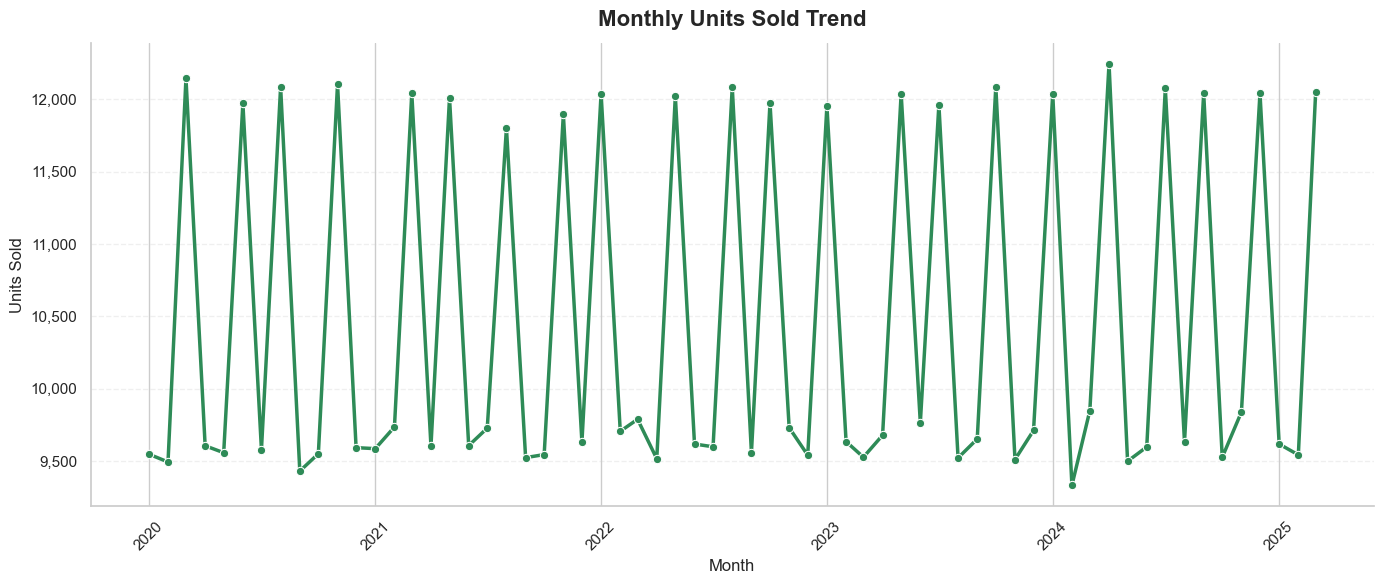

In [33]:
# ----------------------------------------
# T-01: Monthly Units Sold Trend
# ----------------------------------------

# Create figure
plt.figure(figsize=(14,6))

# Create line chart
ax = sns.lineplot(
    data=monthly_units_df,
    x="month",
    y="total_units_sold",
    color="#2E8B57",
    marker="o",
    linewidth=2.5,
    markersize=6
)

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# Titles
plt.title(
    "Monthly Units Sold Trend",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)

plt.xticks(rotation=45)

# Styling
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

# Show chart
plt.show()

### Key Findings

- Monthly units sold remained stable throughout the analysis period, fluctuating between approximately **9.3K** and **12.2K** units.
- No sustained upward or downward trend is observed, indicating consistent product demand over time.

# Correlation Analysis

This section examines the strength and direction of relationships between numerical variables using a correlation matrix.

## C-01: Correlation Heatmap

### Business Objective

Evaluate relationships between key numerical variables to identify factors that are most strongly associated with revenue.

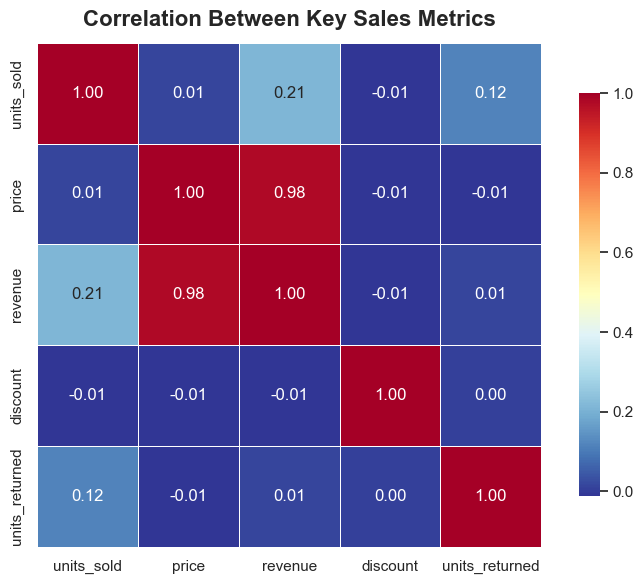

In [34]:
# ----------------------------------------
# C-01: Correlation Heatmap
# ----------------------------------------

# Select numerical columns
corr_df = main_df[
    [
        "units_sold",
        "price",
        "revenue",
        "discount",
        "units_returned"
    ]
]

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Create figure
plt.figure(figsize=(8,6))

# Create heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

# Title
plt.title(
    "Correlation Between Key Sales Metrics",
    fontsize=16,
    fontweight="bold",
    pad=12

)

plt.tight_layout()

plt.show()

### Key Findings

- **Price** has a **very strong positive correlation** with **Revenue** (**0.98**), indicating that higher-priced products generally generate higher transaction revenue.
- **Discount** shows virtually **no correlation** with Revenue (**-0.01**), suggesting that discount levels had minimal influence on revenue in this dataset.

# Business Insights

1. **Vitamin** and **Mineral** categories generated the highest total revenue, making them the strongest-performing product categories.

2. **Canada** recorded the highest overall revenue, although sales performance remained relatively balanced across all three countries.

3. **iHerb** generated the highest revenue among sales platforms, with Amazon and Walmart showing comparable performance.

4. Transaction revenue remained stable throughout the analysis period, with no significant long-term upward or downward trend.

5. Discount levels showed little to no relationship with transaction revenue, indicating that discounts were not a major driver of sales performance.

6. Product price exhibited a very strong positive correlation with revenue, suggesting that higher-priced products contributed substantially to overall sales revenue.

7. Units sold showed a moderate positive relationship with revenue, confirming that both sales volume and pricing influence business performance.

# Summary

This notebook analyzed the cleaned nutrition sales dataset using SQL and Python to explore sales performance, product trends, customer purchasing patterns, and relationships between key business metrics.

The analysis identified high-performing product categories, countries, and sales platforms while highlighting stable sales trends over time. Correlation analysis further showed that product pricing has a stronger influence on revenue than discount levels.

These findings complement the Power BI dashboard by providing detailed exploratory analysis and supporting data-driven business decision-making.